In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys

import pandas as pd
    
sys.path.insert(1, "../../")

import precision_mapping as pm
import CAP_tools


sys.path.insert(1, "../../network_control")
import surface_mapping as sfm

# HCP PM Pipeline 

### Parameters

In [2]:
exclude_subcortex = True
mask = False
sparsity = 0.1

silent = True

pm.utils.printer.silent = silent

### paths

In [4]:
results_dir = "/data/data7/network_control/results/HCP_7T_analysis/precision_maps/rfMRI_REST_7T_ALL"
dtseries_list_txt = "/data/data7/network_control/scripts/_params/HCP_7T_CAP_analysis/HCP_7T_CAP_analysis_rfMRI_REST_7T_ALL_dtseries_list.txt"

with open(dtseries_list_txt) as file:
    dtseries_paths = file.read().strip().split()

cached_dtseries_paths = pm.utils.cache_tmp_path(dtseries_paths, write_cache=False)

subjects = [path.split("/MNINon")[0].split("/")[-1] for path in dtseries_paths]

voxel_FC_file_ending = "voxel_FC.npz"
parcel_file_ending = "parcellation.npy"
network_file_ending = "networks.npy"

# TODO: Correlations are fixed, now add other steps in pipelines

In [5]:
overwrite = False

In [6]:
# for max_trs in [None, 300, 1200, 2400, 3000]:
# for max_trs in [300, 600, 1200, 1500, 1800, 2100, 2400, 2700, 3000, 3300, None]:
for max_trs in [3500, 3550]:
    generic_save_paths = []
    for subject in subjects:
        label_tag = pm.utils.create_path_tag(subject, sparsity, mask, exclude_subcortex, max_trs=max_trs)
        generic_save_paths.append(f"{results_dir}/{subject}/{label_tag}_{{file_ending}}")
        # print()
        os.makedirs(f"{results_dir}/{subject}", exist_ok=True)

    voxel_FC_save_paths = [path.format(file_ending=voxel_FC_file_ending) for path in generic_save_paths]
    parcel_save_paths = [path.format(file_ending=parcel_file_ending) for path in generic_save_paths]
    network_save_paths = [path.format(file_ending=network_file_ending) for path in generic_save_paths]
    
    # _ = pm.functional_connectivity.generate_correlation_matrix(cached_dtseries_paths, voxel_FC_save_paths, block_size=1000,
    #                                                            max_trs=max_trs, overwrite=overwrite, backend="torch", device="mps")

    # pm.parcellate.parcel_detection(voxel_FC_save_paths, parcel_save_paths, n_cores=5, n_reps=50, overwrite=overwrite)
    
    # pm.na.assign_networks_batch(cached_dtseries_paths, parcel_save_paths, network_save_paths, overwrite=overwrite)

# TODO:

- Create network assignment files (one based on FC + spatial, one just spatial, probably dlabels or npy, also save network assignment weights)

In [19]:
import torch

In [21]:
torch.backends.mps.is_available()

False

# Multi-echo Dtseries

In [32]:
dtseries_path = "/data/data7/juanMRI/ZI/xcp-0.10.0rc3/sub-zitestpfm/func/sub-zitestpfm_task-rest_space-fsLR_den-91k_desc-denoised_bold.dtseries.nii"

ME_filename = "ME_example"

voxel_fc_path = f"scratch/{ME_filename}_voxel_FC.npz"
parcellation_path = f"scratch/{ME_filename}_parcellation.npy"
network_path = f"scratch/{ME_filename}_networks.npy"

In [117]:
overwrite=False

# voxel_FC = pm.functional_connectivity.generate_correlation_matrix(dtseries_path, voxel_fc_path, block_size=1000,
#                                                                   overwrite=False, backend="torch", device="cpu")
# pm.parcellate.parcel_detection([voxel_fc_path], [parcellation_path], n_cores=5, n_reps=50, overwrite=overwrite, silent=False)
r = pm.na.assign_networks_batch([dtseries_path], [parcellation_path], [network_path], overwrite=True)

  0%|          | 0/1 [00:00<?, ?it/s]

0.0
0.0
0.0
Created network assignments.


In [118]:
import numpy as np
import matplotlib.pyplot as plt

In [119]:
def load_FC_cortex(FC_path, template_cifti):
    """ """
    sc = scipy.sparse.load_npz(FC_path)
    cortex_index = pm.na.get_cortex_data(np.arange(sc.shape[0]).reshape(1, -1), template_cifti)[0]
    return sc[cortex_index][:, cortex_index]

def load_partition_labels(partition_path, template_cifti):
    """ """
    partition = np.load(partition_path)
    vertex_labels = pm.na.get_partition_cortex(partition, template_cifti)
    vertex_labels[np.isnan(vertex_labels)] = np.nanmax(vertex_labels) + 1
    remapped_vertex_labels = np.unique(vertex_labels, return_inverse=True)[1]
    return remapped_vertex_labels

In [120]:
def load_network_labels(network_path):
    return np.load(network_save_path)[0].astype(int)

In [121]:
vni, vns = np.load(network_path)
example_cifti = nb.load(dtseries_path)

In [122]:
pni = load_partition_labels(parcellation_path, example_cifti)

In [123]:
def vertex_plot(values, template_cifti, ax=None, pclip=(None, None), **kwargs):
    """ """
    values = CAP_tools.utils.cifti_map(None, values, template_cifti)
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))
    return sfm.surface_plot(values, ax=ax, **kwargs)

(<Axes: >, <surfplot.plotting.Plot at 0x15a289d90>)

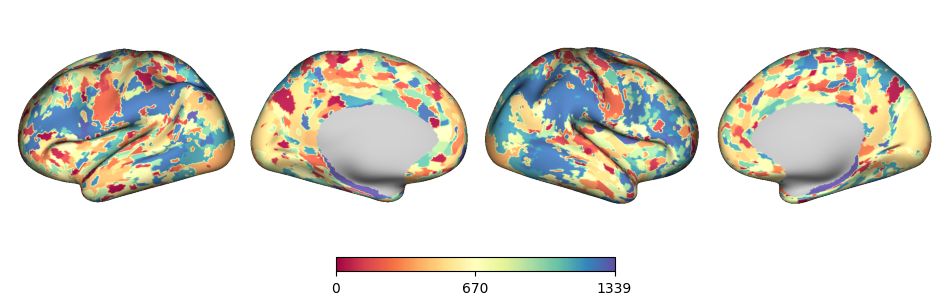

In [124]:
vertex_plot(pni, example_cifti, cmap=plt.cm.Spectral)

(<Axes: >, <surfplot.plotting.Plot at 0x30ebdb290>)

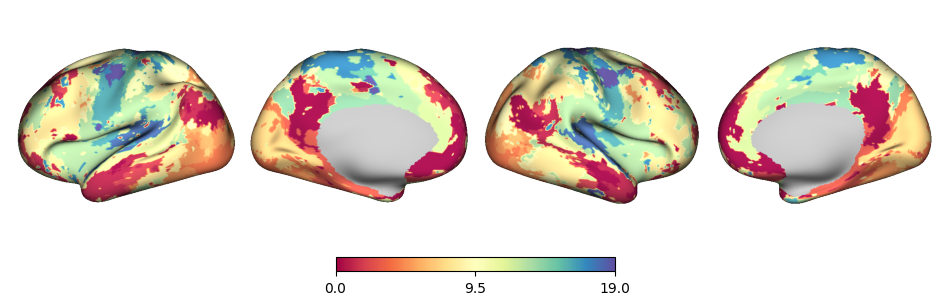

In [135]:
vni_shuffled = np.random.choice(np.arange(20), 20,  replace=False)[vni.astype(int)]
vertex_plot(vni, example_cifti, cmap=plt.cm.Spectral)

In [148]:
pair_data = np.array([data[:600].T, data[600:].T])

In [202]:
cortex_data = pm.na.get_cortex_data(data, example_cifti)
pair_data = np.array([cortex_data[:100].T, cortex_data[-100:].T])
pair_data = np.array([cortex_data[:50].T, cortex_data[-50:].T])
# pair_data = np.array([cortex_data[1::2].T, cortex_data[::2].T])

In [203]:
import xmath_tools as xmt
r = xmt.PairCorrelator.run(pair_data, axis=None, threshold=None, backend="torch", device="cpu")
print(r, r ** 2)

tensor(0.0094)
tensor(0.0094)


PairCorrelator Block Analysis:   0%|          | 0/3600.0 [00:00<?, ?it/s]

0.5458 0.29789763999999996


(<Axes: >, <surfplot.plotting.Plot at 0x390ea4a50>)

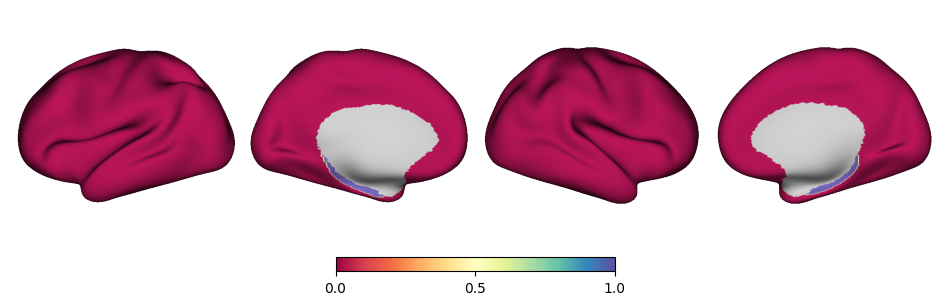

In [185]:
zeros = np.std(data, axis=0) == 0
vertex_plot(zeros, example_cifti, cmap=plt.cm.Spectral)

In [195]:
RS_3T_path = "/System/Volumes/Data/data/data6/earlycort_7114/ec_00_0005/MNINonLinear/Results/RS_fMRI_maps/RS_fMRI_maps_Atlas_mov_regr_b_lt_resid_brain_regr_resid_frcintrp_bpss_lc2353_hc2.dtseries.nii"

RS_3T_path = "/System/Volumes/Data/data/data6/earlycort_7114/ec_00_0005/MNINonLinear/Results/RS_fMRI_maps/RS_fMRI_maps_Atlas_mov_regr_b_lt_resid_brain_regr_resid_DV_FDadapt_frcintrp_bpss_lc2353_hc2_fwhm4.dtseries.nii"

In [196]:
cifti_3T = nb.load(RS_3T_path)

cortex_data_3T = pm.na.get_cortex_data(cifti_3T.get_fdata(), cifti_3T)
pair_data_3T = np.array([cortex_data_3T[:600].T, cortex_data_3T[600:1200].T])

In [197]:
r_3T = xmt.PairCorrelator.run(pair_data_3T, axis=None, threshold=None, backend="torch", device="cpu")
print(r_3T, r_3T ** 2)

tensor(0.)
tensor(0.)


PairCorrelator Block Analysis:   0%|          | 0/3600.0 [00:00<?, ?it/s]

0.61643 0.37998594490000004
